# 라이브 3 실습

데이터 시각화와 전처리


## 실습 방법

- 코드 셀의 `None`을 알맞은 값이나 코드로 바꾼 뒤 실행합니다.
- 오른쪽 주석에서 예상 결과를 확인할 수 있습니다.
- 셀은 위에서부터 순서대로 실행합니다.
- 정답 노트북은 강사용이며 실습을 마친 뒤 함께 확인합니다.


## 설치와 한글 폰트

라이브러리가 설치되어 있다면 `!pip install` 줄은 건너뜁니다.

Matplotlib의 기본 폰트에서 한글이 깨질 수 있습니다. 아래 셀은 운영체제에 맞는 한글 폰트를 설정하고, 사용할 수 있는 폰트가 없으면 제목과 축 이름을 영어로 표시합니다.


In [17]:
# !pip install -q "numpy>=2.5.0,<3" "pandas>=3.0.0,<4" "matplotlib>=3.11.0,<3.13" "seaborn>=0.13.2,<0.14"
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import os
import matplotlib.font_manager as fm

# # 운영체제에 맞는 한글 폰트 설정
# _target = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system(), "NanumGothic")
# _available = {f.name for f in font_manager.fontManager.ttflist}
# KOREAN_FONT_OK = _target in _available
# if KOREAN_FONT_OK:
#     plt.rcParams["font.family"] = _target
# plt.rcParams["axes.unicode_minus"] = False   # 음수 부호가 깨지는 현상 방지

font_path = './fonts/NanumGothic-Regular.ttf'

if os.path.exists(font_path):
    # 1. 폰트 매니저에 TTF 파일 등록
    fm.fontManager.addfont(font_path)
    # 2. 파일에서 실제 폰트 패밀리 이름 추출 후 설정
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
else:
    print(f"경고: {font_path} 파일이 존재하지 않습니다.")

def L(ko, en):
    """한글 폰트가 있으면 한글, 없으면 영어 라벨을 반환한다."""
    return ko if KOREAN_FONT_OK else en

print("matplotlib:", plt.matplotlib.__version__, "| seaborn:", sns.__version__)
print("한글 폰트:", "사용 가능" if KOREAN_FONT_OK else "미설치, 영어 라벨로 표시")

matplotlib: 3.11.1 | seaborn: 0.13.2
한글 폰트: 미설치, 영어 라벨로 표시


## 카페 데이터

라이브 2에서 사용한 카페 음료 판매 데이터를 다시 만듭니다. `seed=42`로 고정했으므로 같은 값이 생성됩니다.


In [18]:
np.random.seed(42)
n = 200
지역 = np.random.choice(["서울", "부산", "대전", "광주"], n)
메뉴 = np.random.choice(["아메리카노", "카페라떼", "바닐라라떼"], n)
단가 = np.random.choice([4000, 4500, 5000, 5500, 6000], n)
수량 = np.random.randint(1, 6, n)

df = pd.DataFrame({"지역": 지역, "메뉴": 메뉴, "단가": 단가, "수량": 수량})
df["매출"] = df["단가"] * df["수량"]

print(df.shape)   # (200, 5)
df.head()

(200, 5)


,지역,메뉴,단가,수량,매출
0,대전,바닐라라떼,4000,5,20000
1,광주,바닐라라떼,6000,3,18000
2,서울,아메리카노,5000,3,15000
3,대전,아메리카노,5500,1,5500
4,대전,카페라떼,4000,4,16000


## 막대그래프와 꺾은선그래프

- `plt.bar(x, y)` : 범주별 값을 막대그래프로 비교
- `plt.plot(x, y, marker="o")` : 시간에 따른 변화를 꺾은선그래프로 표시


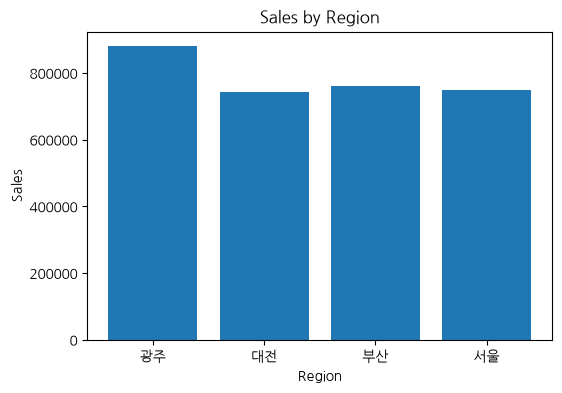

In [19]:
지역별매출 = df.groupby("지역")["매출"].sum()

plt.figure(figsize=(6, 4))
# 지역별 매출을 막대그래프로 그려 보세요
높이 = 지역별매출.values                         # 지역별매출.values
plt.bar(지역별매출.index, 높이)
plt.title(L("지역별 매출", "Sales by Region"))
plt.xlabel(L("지역", "Region"))
plt.ylabel(L("매출", "Sales"))
plt.show()

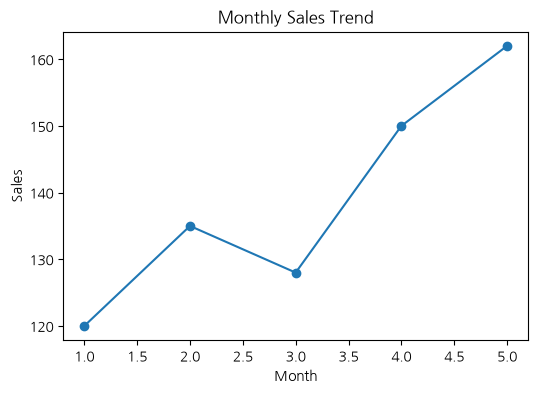

In [20]:
월별매출 = [120, 135, 128, 150, 162]   # 1월부터 5월까지 (가상)

plt.figure(figsize=(6, 4))
# 1부터 5까지의 월을 x축으로 만들어 보세요
개월 = range(1, 6)                          # range(1, 6)
plt.plot(개월, 월별매출, marker="o")
plt.title(L("월별 매출 추이", "Monthly Sales Trend"))
plt.xlabel(L("월", "Month"))
plt.ylabel(L("매출", "Sales"))
plt.show()

## 히스토그램과 산점도

- `plt.hist(값, bins=5)` : 값의 분포를 히스토그램으로 표시
- `plt.scatter(x, y)` : 두 값의 관계를 산점도로 표시
- `plt.subplots(행, 열)` : 지정한 행과 열만큼 차트 영역을 생성


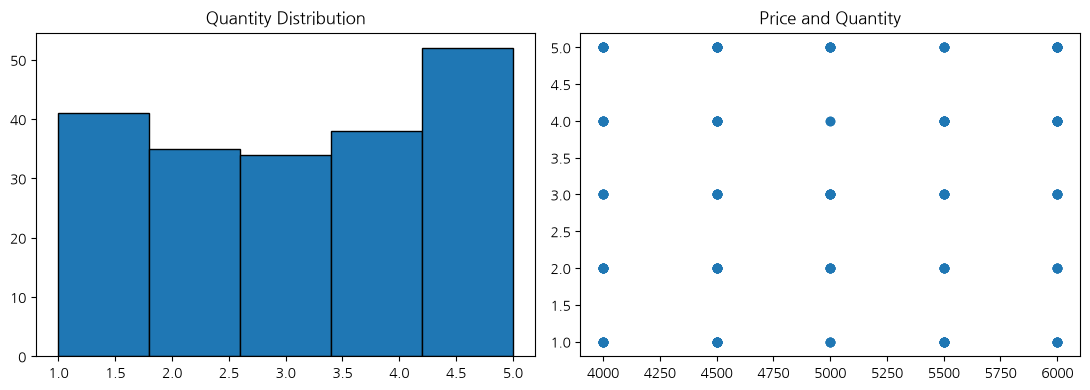

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["수량"], bins=5, edgecolor="black")
axes[0].set_title(L("수량 분포", "Quantity Distribution"))

# 단가와 수량의 산점도를 그려 보세요
y값 = df["수량"]                          # df["수량"]
axes[1].scatter(df["단가"], y값)
axes[1].set_title(L("단가와 수량", "Price and Quantity"))

plt.tight_layout()
plt.show()

## Seaborn 통계 시각화

- `sns.barplot` : 범주별 평균을 비교
- `sns.boxplot` : 값의 분포와 이상치를 확인
- `sns.heatmap` : 상관관계와 같은 행렬 데이터를 표현


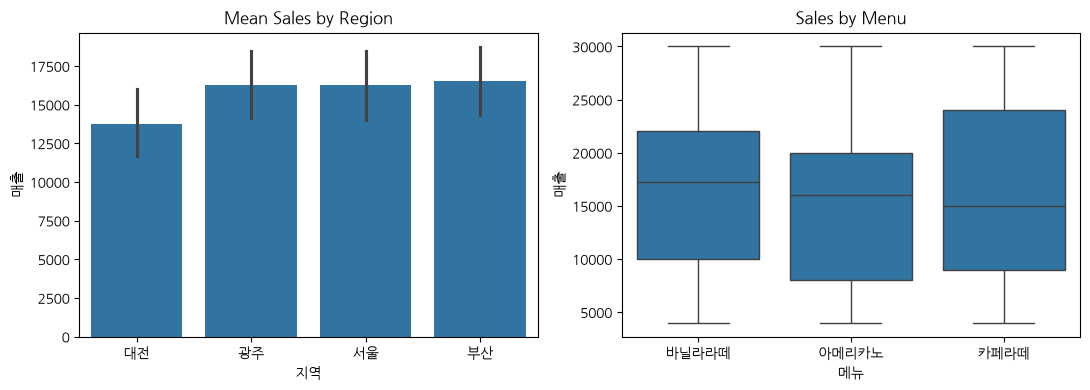

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=df, x="지역", y="매출", ax=ax1)   # 지역별 평균 매출
ax1.set_title(L("지역별 평균 매출", "Mean Sales by Region"))

# 메뉴별 매출 분포를 boxplot 으로 그려 보세요 (x축은 "메뉴")
가로축 = "메뉴"                        # "메뉴"
sns.boxplot(data=df, x=가로축, y="매출", ax=ax2)
ax2.set_title(L("메뉴별 매출 분포", "Sales by Menu"))

plt.tight_layout()
plt.show()

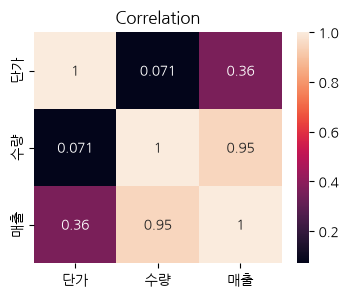

In [23]:
상관표 = df.corr(numeric_only=True)   # 숫자 컬럼끼리의 상관계수

plt.figure(figsize=(4, 3))
# 상관관계를 heatmap으로 그려 보세요 (칸마다 숫자를 표시하려면 annot=True)
숫자표시 = True                       # True
sns.heatmap(상관표, annot=숫자표시)
plt.title(L("상관관계", "Correlation"))
plt.show()

## 결측치 처리

- `df["컬럼"].isnull().sum()` : 결측치 개수를 확인
- `fillna(값)` : 결측치를 지정한 값으로 대체
- 평균은 이상치의 영향을 받으므로 분포가 치우치면 중앙값을 사용


In [24]:
df2 = df.copy()
df2["단가"] = df2["단가"].astype("float")
df2.loc[5, "단가"] = np.nan          # 결측치 1개 주입
print("결측치 개수:", df2["단가"].isnull().sum())   # 1

평균단가 = df2["단가"].mean()         # 결측치를 제외하고 평균 계산
# 단가 결측치를 평균 단가로 채우고 다시 df2["단가"]에 담아 보세요
df2["단가"] = df2["단가"].fillna(평균단가)                    # df2["단가"].fillna(평균단가)
print("남은 결측치:", df2["단가"].isnull().sum())   # 0

결측치 개수: 1
남은 결측치: 0


## apply와 구간화

- `apply()` : 컬럼의 각 값에 함수를 적용
- `pd.qcut(컬럼, n)` : 각 구간의 데이터 수가 비슷하도록 n개 구간으로 나눔
- `pd.cut(컬럼, n)` : 값의 범위를 같은 폭의 n개 구간으로 나눔


In [27]:
def grade(x):
    if x >= 5000:
        return "고가"
    else:
        return "저가"

# apply로 grade를 적용해 가격대 컬럼을 만들어 보세요
df["가격대"] = df["단가"].apply(grade)                  # df["단가"].apply(grade)
print(df["가격대"].value_counts())

df["매출구간"] = pd.qcut(df["매출"], 5)   # 동일 빈도 5구간
print(df["매출구간"].value_counts())

df["매출구간"] = pd.cut(df["매출"], 5)
print(df["매출구간"].value_counts())

가격대
고가    110
저가     90
Name: count, dtype: int64
매출구간
(12000.0, 18000.0]    44
(3999.999, 6000.0]    41
(6000.0, 12000.0]     41
(22500.0, 30000.0]    39
(18000.0, 22500.0]    35
Name: count, dtype: int64
매출구간
(3974.0, 9200.0]      59
(19600.0, 24800.0]    45
(14400.0, 19600.0]    37
(9200.0, 14400.0]     30
(24800.0, 30000.0]    29
Name: count, dtype: int64


## 타이타닉 데이터 EDA

- 탐색적 데이터 분석(EDA) : 데이터의 분포와 문제를 파악하는 과정
- Seaborn의 타이타닉 승객 데이터에서 생존 요인을 확인

Seaborn 로드와 CSV 주소가 모두 실패하면 함께 배포된 `data/titanic.csv`를 불러옵니다. 아래 셀은 수정하지 않고 실행합니다.


In [28]:
from pathlib import Path

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
TITANIC_LOCAL_CANDIDATES = [Path("data/titanic.csv"), Path("../data/titanic.csv")]

try:
    titanic = sns.load_dataset("titanic")
    출처 = "seaborn"
except Exception as seaborn_error:
    print("seaborn 로드 실패, CSV 주소에서 직접 읽기:", seaborn_error)
    try:
        titanic = pd.read_csv(TITANIC_URL)
        출처 = "CSV URL"
    except Exception as url_error:
        local_path = next((path for path in TITANIC_LOCAL_CANDIDATES if path.exists()), None)
        if local_path is None:
            raise FileNotFoundError("data/titanic.csv를 찾을 수 없습니다. 배포 폴더 구조를 확인하세요.") from url_error
        print("CSV 주소 로드 실패, 로컬 데이터 사용:", url_error)
        titanic = pd.read_csv(local_path)
        출처 = f"로컬 CSV ({local_path})"

print("데이터 출처:", 출처, "| 크기:", titanic.shape)   # (891, 15)
titanic.head()

데이터 출처: seaborn | 크기: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 그룹별 생존율

- `survived`는 0과 1로 구성되어 있어 평균값을 생존율로 볼 수 있음
- `groupby`로 성별, 등급별 생존율을 계산


In [29]:
# 성별 생존율을 구해 보세요 (survived의 평균이 생존율)
성별생존율 = titanic.groupby("sex")["survived"].mean()      # titanic.groupby("sex")["survived"].mean()
print(성별생존율)

# 등급별 생존율
print(titanic.groupby("pclass")["survived"].mean())

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


## 실습 확인

- 막대그래프, 꺾은선그래프, 히스토그램, 산점도
- 한글 폰트 설정
- `barplot`, `boxplot`, `heatmap`
- 결측치 처리와 구간화
- `groupby`를 이용한 그룹별 집계


---

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW,AI아카데미의 콘텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.